In [1]:
import glob
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import os

import scanpy as sc
import seaborn as sns

from scroutines import basicu
from scroutines import powerplots

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tools.sm_exceptions import ValueWarning
from tqdm import tqdm

sns.set_context('talk')

In [2]:
outfigdir = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/results_v1astro'

In [3]:
f = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/annot/gencode.vM25.genebody.bed'
df_annot = pd.read_csv(f, sep='\t', header=None)
df_annot

,0,1,2,3
0,chr1,3073253,3074322,4933401J01Rik
1,chr1,3102016,3102125,Gm26206
2,chr1,3205901,3671498,Xkr4
3,chr1,3252757,3253236,Gm18956
4,chr1,3365731,3368549,Gm37180
...,...,...,...,...
55396,chrM,13552,14070,mt-Nd6
55397,chrM,14071,14139,mt-Te
55398,chrM,14145,15288,mt-Cytb
55399,chrM,15289,15355,mt-Tt


In [4]:
filename = os.path.join(outfigdir, f'NRDR_DEGs_LMM_astro_cheng22_d260210_Astro_A.h5ad')
res_a = sc.read(filename)

filename = os.path.join(outfigdir, f'NRDR_DEGs_LMM_astro_cheng22_d260210_Astro_B.h5ad')
res_b = sc.read(filename)

In [5]:
res_a.var, res_b.var

(Empty DataFrame
 Columns: []
 Index: [Intercept, Time[T.P38], Light[T.NR], Time[T.P38]:Light[T.NR], Sample Var],
 Empty DataFrame
 Columns: []
 Index: [Intercept, Time[T.P38], Light[T.NR], Time[T.P38]:Light[T.NR], Sample Var])

In [6]:
res = res_a
print(res.layers['param'].shape)
print(res.layers['effsize'].shape) # log2FC
print(res.layers['pval'].shape)
print(res.layers['qval'].shape)

(10965, 5)
(10965, 5)
(10965, 5)
(10965, 5)


In [7]:
df_list = []
df_sig_list = []
df_raw_list = []
idx = 2

x_th =  np.log2(1.5)
y_th = -np.log10(0.05)

q_inf = 1e-50
# z = df['max_cp10k']
# z_th = 0.1

for i, res in enumerate([res_a, res_b]):
    
    
    df = res.obs.copy()
    df['l2fc'] = -res.layers['effsize'][:,idx]
    df['l10q'] = -np.log10(res.layers['qval'][:,idx])
    
    # converge, expressed (or not too small q)
    cond_pre = np.logical_and(res.obs['converge'], 
                              res.layers['qval'][:,idx]>q_inf)
    df_raw = df.copy()
    df = df[cond_pre]

    x = df['l2fc'].values 
    y = df['l10q'].values
    
    cond_sig = np.all([np.abs(x) > x_th, 
                       y > y_th, 
                       # z > z_th, 
                      ], axis=0)

    print(np.sum(cond_sig))
    df_sig = df[cond_sig]
    df_sig = df_sig.sort_values('l10q', ascending=False)
    
    df_list.append(df)
    df_sig_list.append(df_sig)
    df_raw_list.append(df_raw)


77
32


/tmp/ipykernel_231083/2903292036.py:18: RuntimeWarning: divide by zero encountered in log10
  df['l10q'] = -np.log10(res.layers['qval'][:,idx])
/tmp/ipykernel_231083/2903292036.py:18: RuntimeWarning: divide by zero encountered in log10
  df['l10q'] = -np.log10(res.layers['qval'][:,idx])


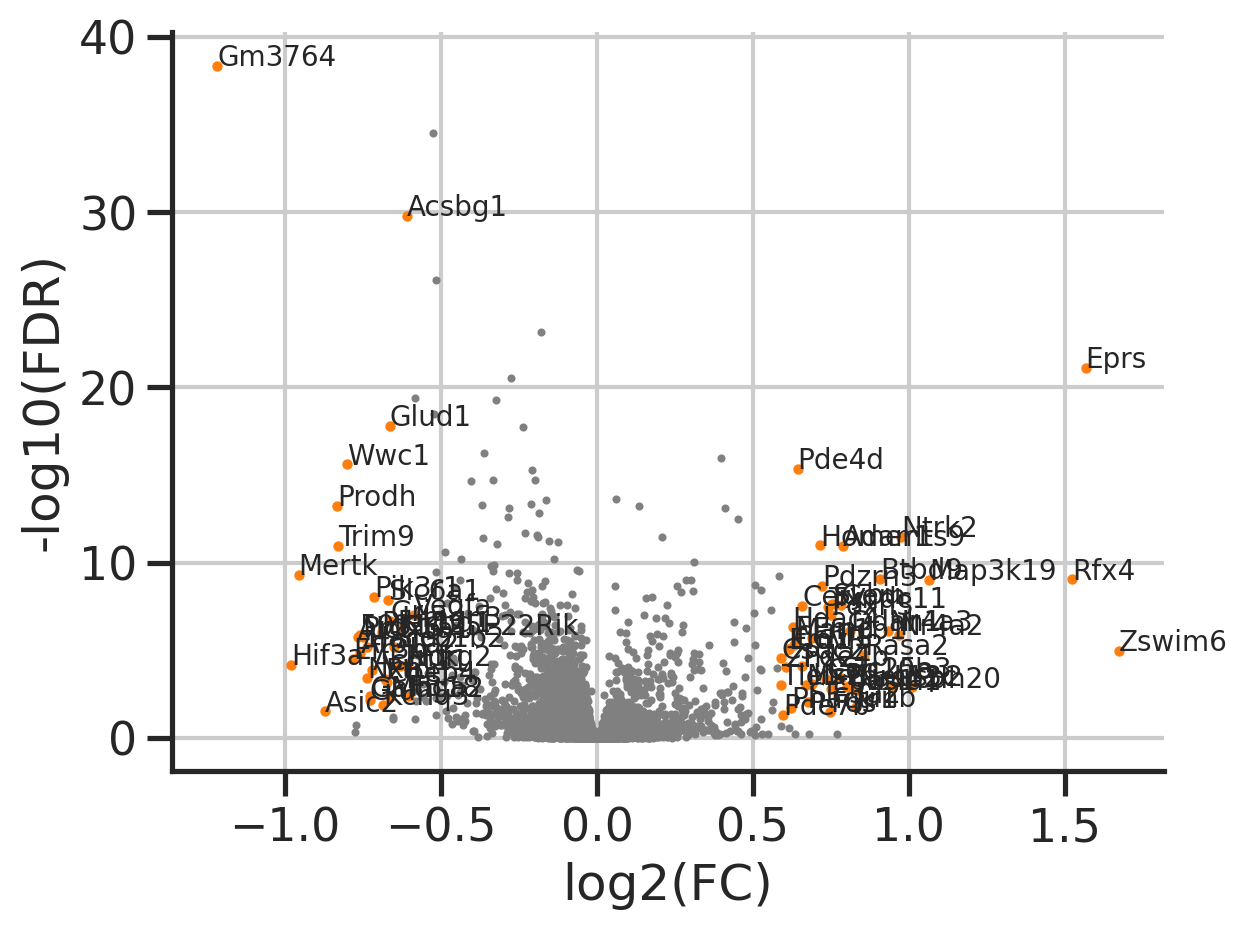

In [8]:
df = df_list[0]
df_sig = df_sig_list[0]

fig, ax = plt.subplots()
ax.scatter(df['l2fc'].values, df['l10q'].values, s=2, color='gray')
ax.scatter(df_sig['l2fc'].values, df_sig['l10q'].values, s=5, color='C1')
for gene, row in df_sig.iterrows():
    x = row['l2fc']
    y = row['l10q']
    ax.text(x,y,gene, fontsize=10)
sns.despine(ax=ax)
ax.set_xlabel('log2(FC)')
ax.set_ylabel('-log10(FDR)')
plt.show()

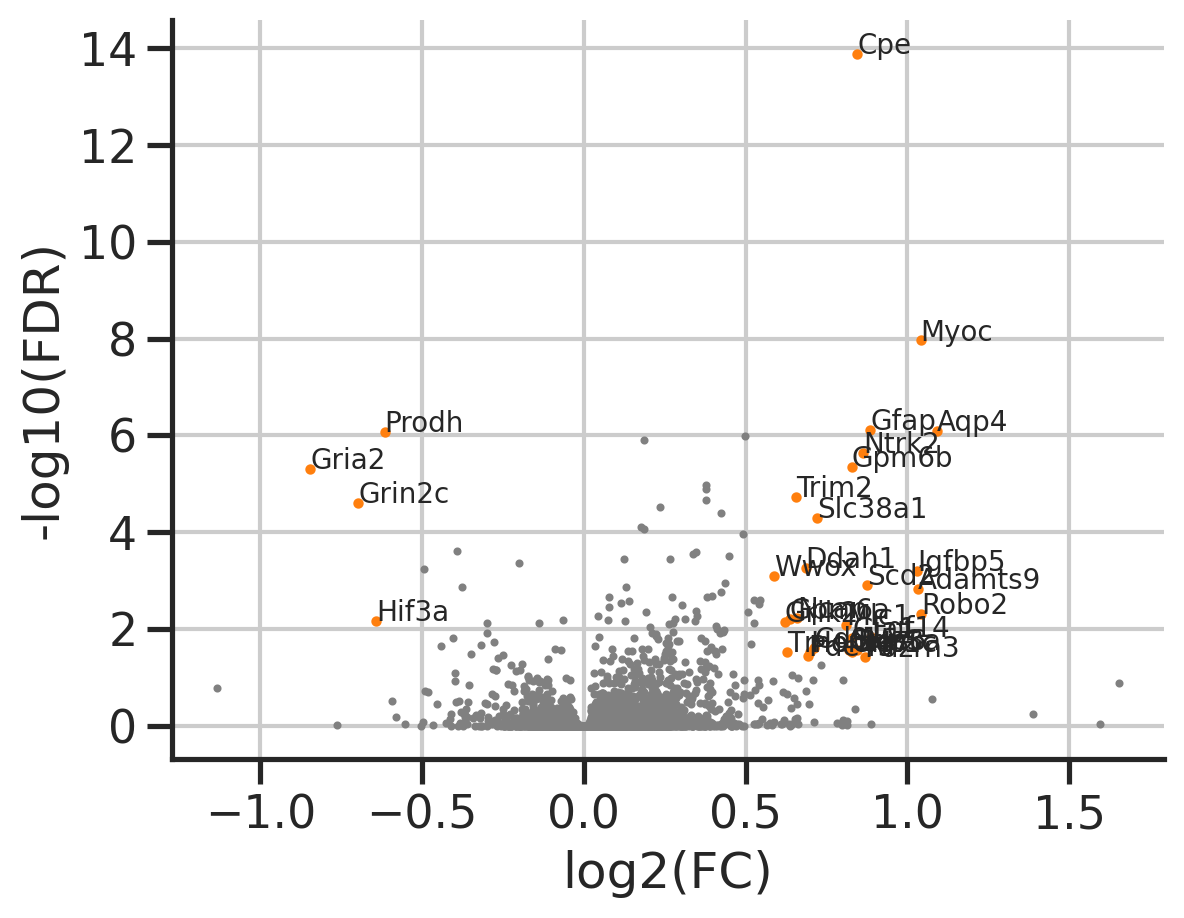

In [9]:
df = df_list[1]
df_sig = df_sig_list[1]

fig, ax = plt.subplots()
ax.scatter(df['l2fc'].values, df['l10q'].values, s=2, color='gray')
ax.scatter(df_sig['l2fc'].values, df_sig['l10q'].values, s=5, color='C1')
for gene, row in df_sig.iterrows():
    x = row['l2fc']
    y = row['l10q']
    ax.text(x,y,gene, fontsize=10)
sns.despine(ax=ax)
ax.set_xlabel('log2(FC)')
ax.set_ylabel('-log10(FDR)')
plt.show()

# cell level data

In [10]:
adata = sc.read("/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/v1_multiome/superdupermegaRNA_hasraw_cheng22_astro.h5ad")
print(adata.X.data)
adata

[ 1. 16.  2. ...  1.  1.  4.]


AnnData object with n_obs × n_vars = 19330 × 16340
    obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden'
    var: 'feature_types'
    layers: 'norm'

In [11]:

exp_conds = ['P28', 'P28_dr', 'P38', 'P38_dr']
adata = adata[adata.obs['Age'].isin(exp_conds)]
adata

View of AnnData object with n_obs × n_vars = 7697 × 16340
    obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden'
    var: 'feature_types'
    layers: 'norm'

In [12]:
# remove mitocondria genes
adata = adata[:,~adata.var.index.str.contains(r'^mt-')]

# remove sex genes
sex_genes = ["Xist", "Uty", "Eif2s3y", "Kdm5d", "Ddx3y"]
adata = adata[:,[g for g in adata.var.index if g not in sex_genes]]

# filter genes
cond = np.ravel((adata.X>0).sum(axis=0)) > 10 # expressed in more than 10 cells
adata = adata[:,cond].copy()
# genes = adata.var.index.values

adata

AnnData object with n_obs × n_vars = 7697 × 15573
    obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden'
    var: 'feature_types'
    layers: 'norm'

In [13]:
offset = 1e-2
scale = 1e4

mat = np.array(adata.X.todense())/adata.obs['n_counts'].values.reshape(-1,1)*scale
adata.layers['cp10k'] = mat
adata.layers['log2cp10k'] = np.log2(1+mat)
adata

AnnData object with n_obs × n_vars = 7697 × 15573
    obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden'
    var: 'feature_types'
    layers: 'norm', 'cp10k', 'log2cp10k'

In [14]:
sample_orders = adata.obs['Sample'].astype(str).unique()
print(sample_orders)

palette = {
    'P28': 'C1', 
    'P38': 'C1', 
    'P28_dr': 'gray', 
    'P38_dr': 'gray', 
    }

['P28_1a' 'P28_1b' 'P28_2a' 'P28_2b' 'P38_1a' 'P38_2a' 'P38_2b'
 'P28_dr_1a' 'P28_dr_1b' 'P28_dr_3a' 'P28_dr_3b' 'P38_dr_1a' 'P38_dr_1b'
 'P38_dr_2a' 'P38_dr_2b']


In [15]:
def plot_one_gene_ax(gene, ax, adata, df_stats):
    """
    """
    dfplot = adata.obs[['Age', 'Sample', 'Type']].copy()
    dfplot[gene] = np.array(adata[:,gene].layers['log2cp10k']).reshape(-1,)
    stats = df_stats.loc[gene]

    sns.violinplot(data=dfplot, x='Sample', hue='Age', palette=palette,
                   order=sample_orders, 
                   dodge=False, y=gene, 
                   cut=0, 
                   ax=ax)
    ax.set_title(f'{gene}')

    ax.text(0.05, 0.95, f'q={np.power(10, -stats.l10q):.2g}, l2fc={stats.l2fc:.2g}, conv {stats.converge}', 
            ha='left',
            transform=ax.transAxes, 
            fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('log2(1+cp10k)', fontsize=12)
    sns.despine(ax=ax)

In [16]:
adata_a = adata[adata.obs['Type']=='Astro_A']
adata_b = adata[adata.obs['Type']=='Astro_B']

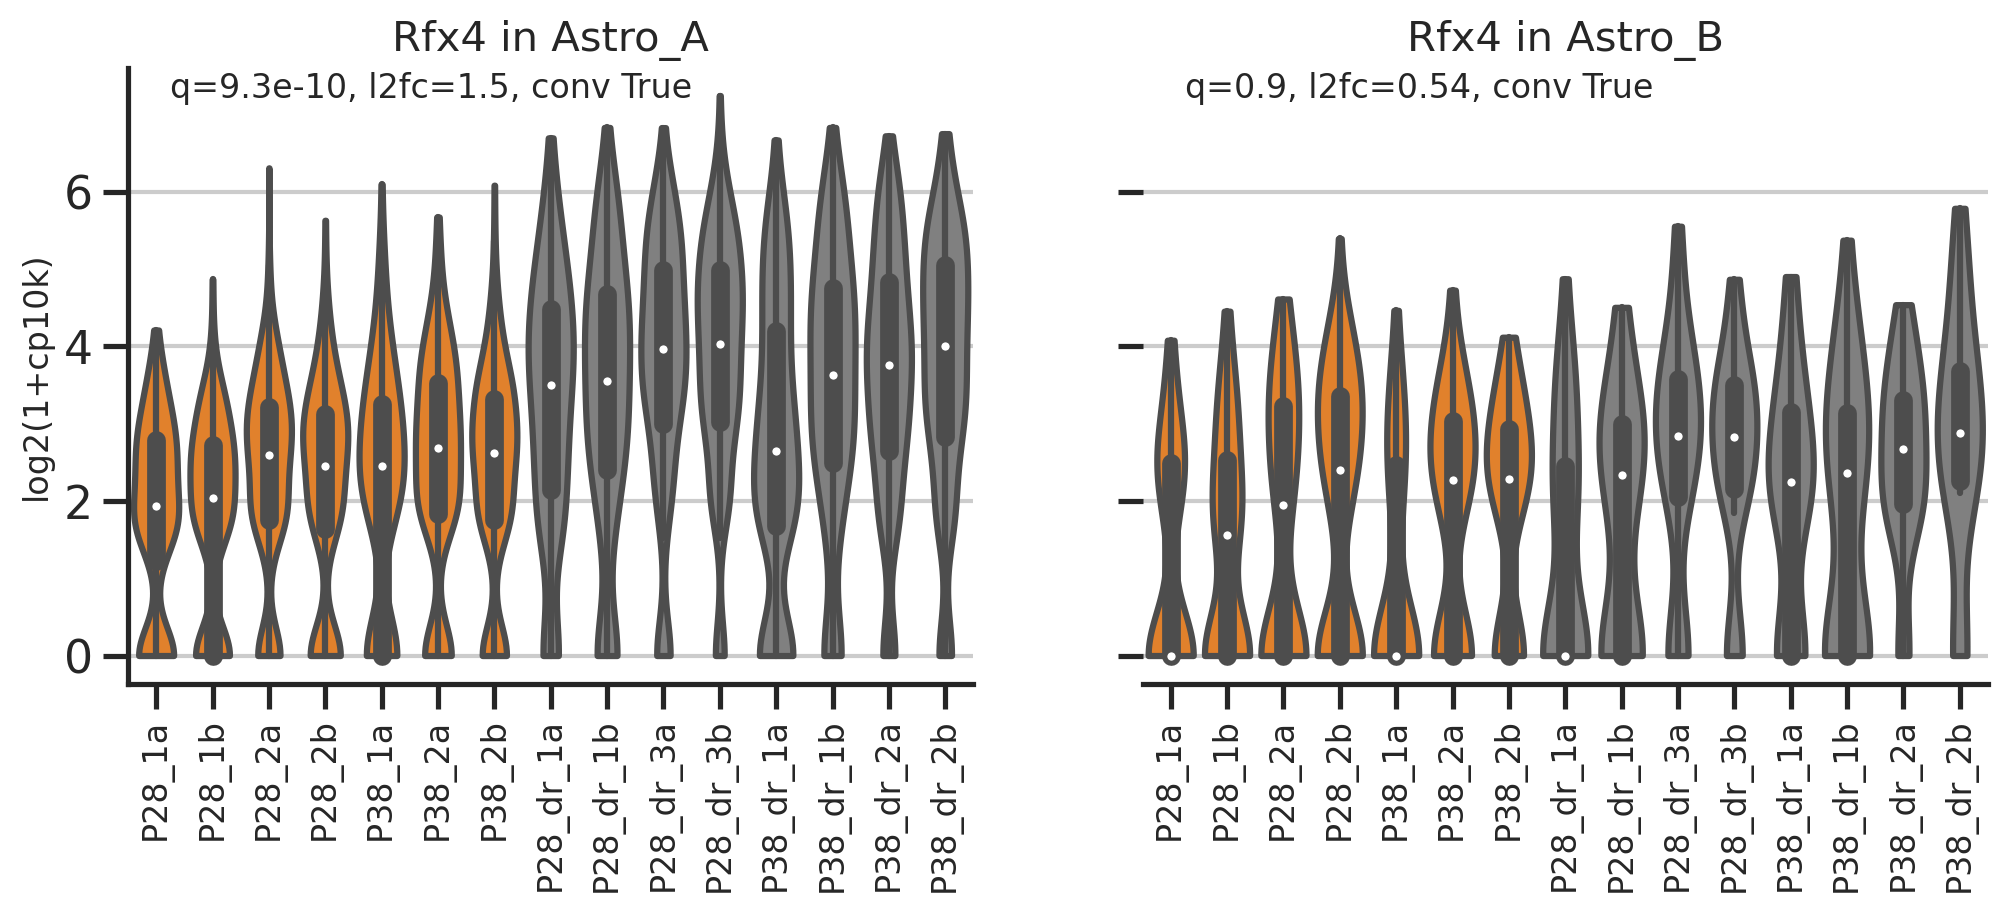

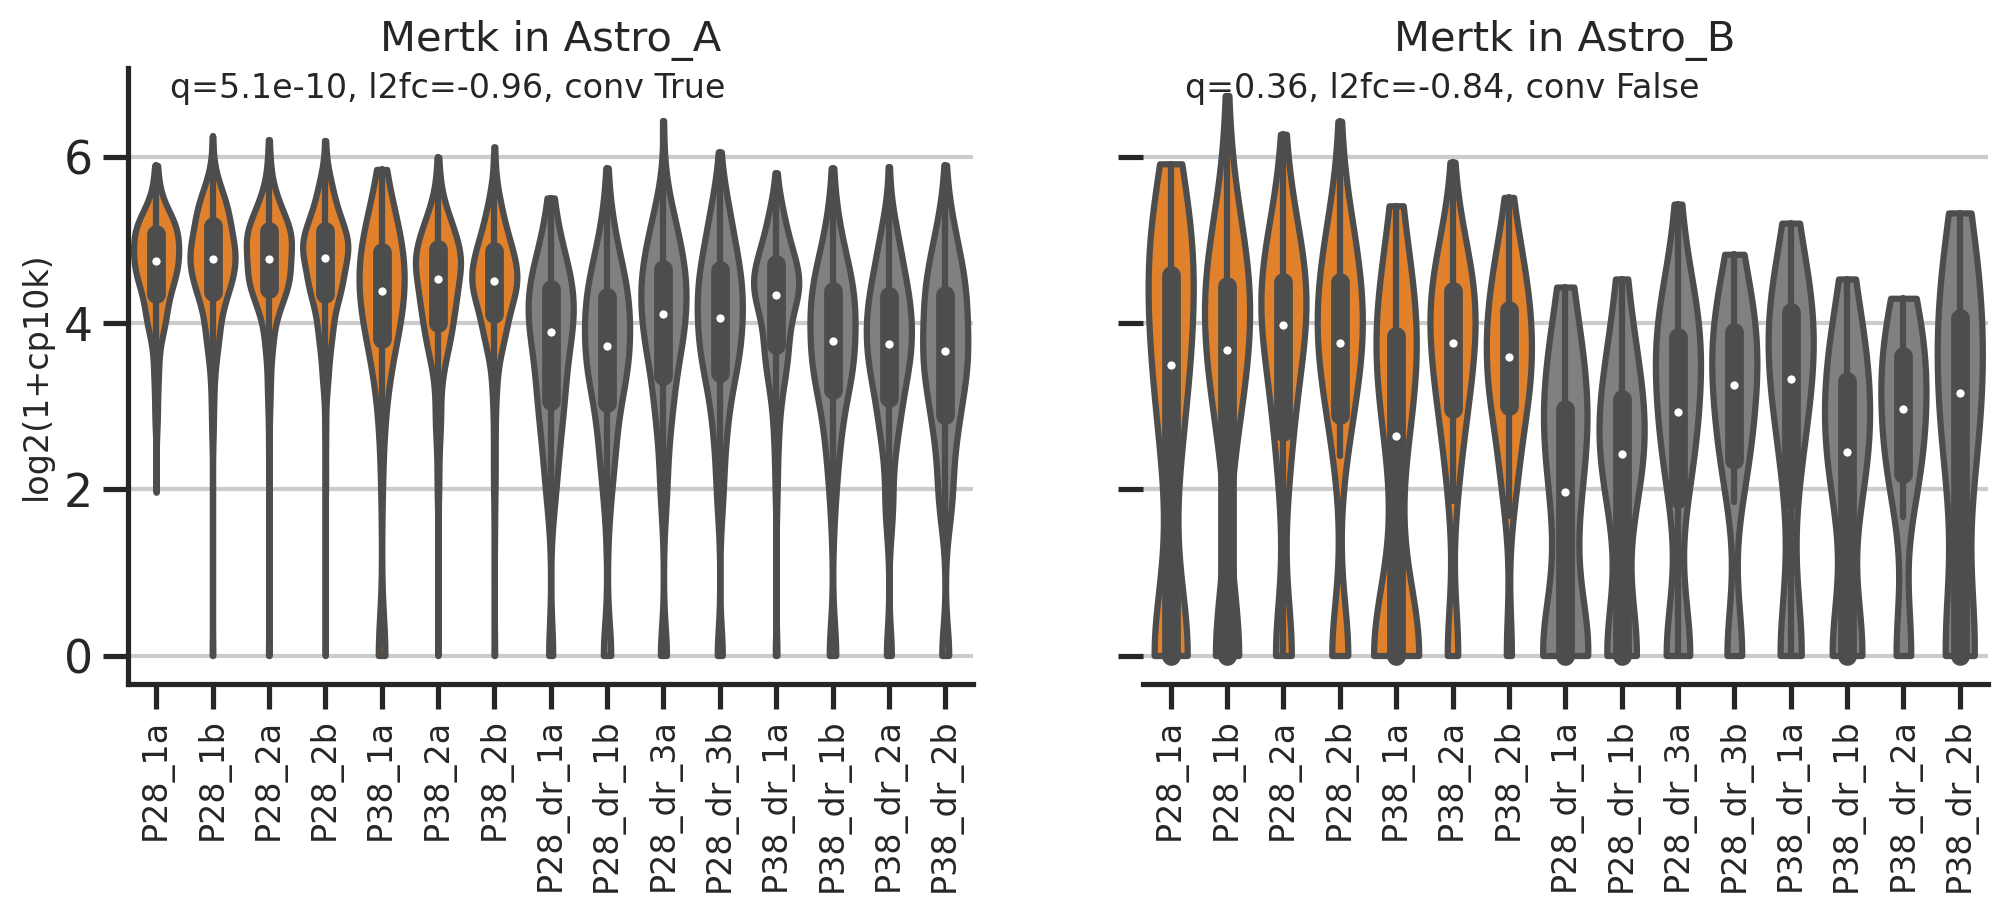

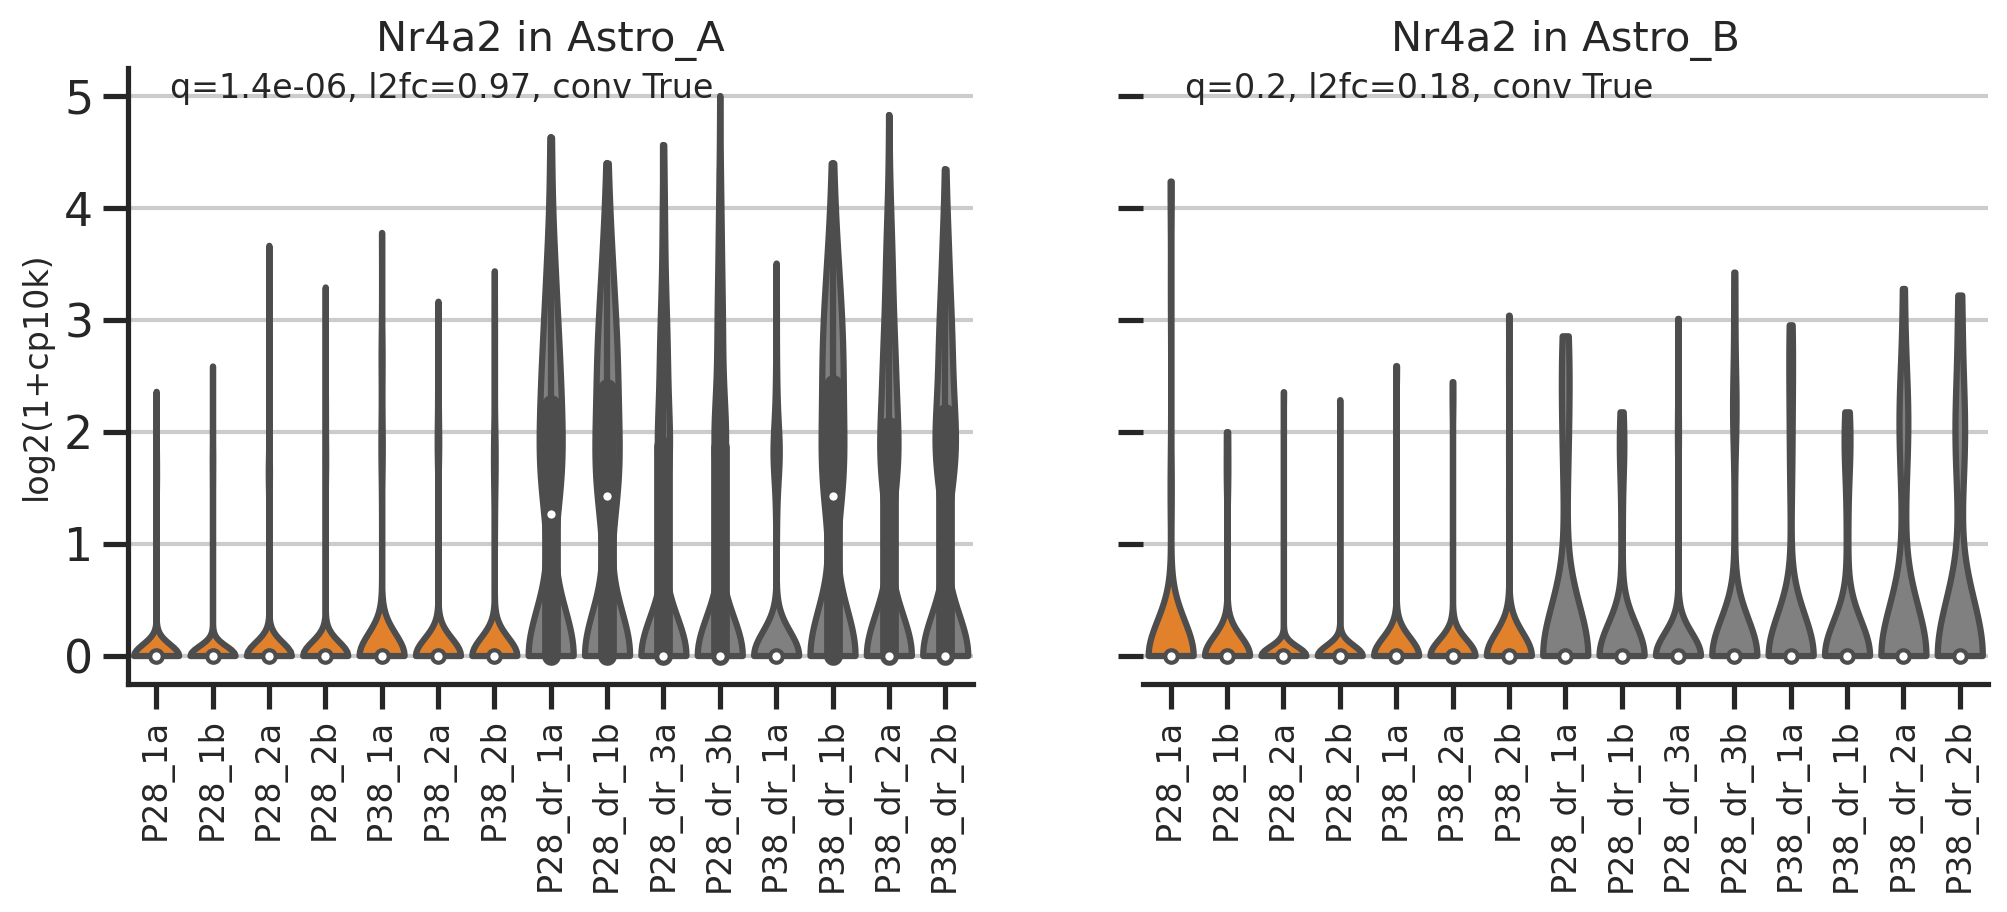

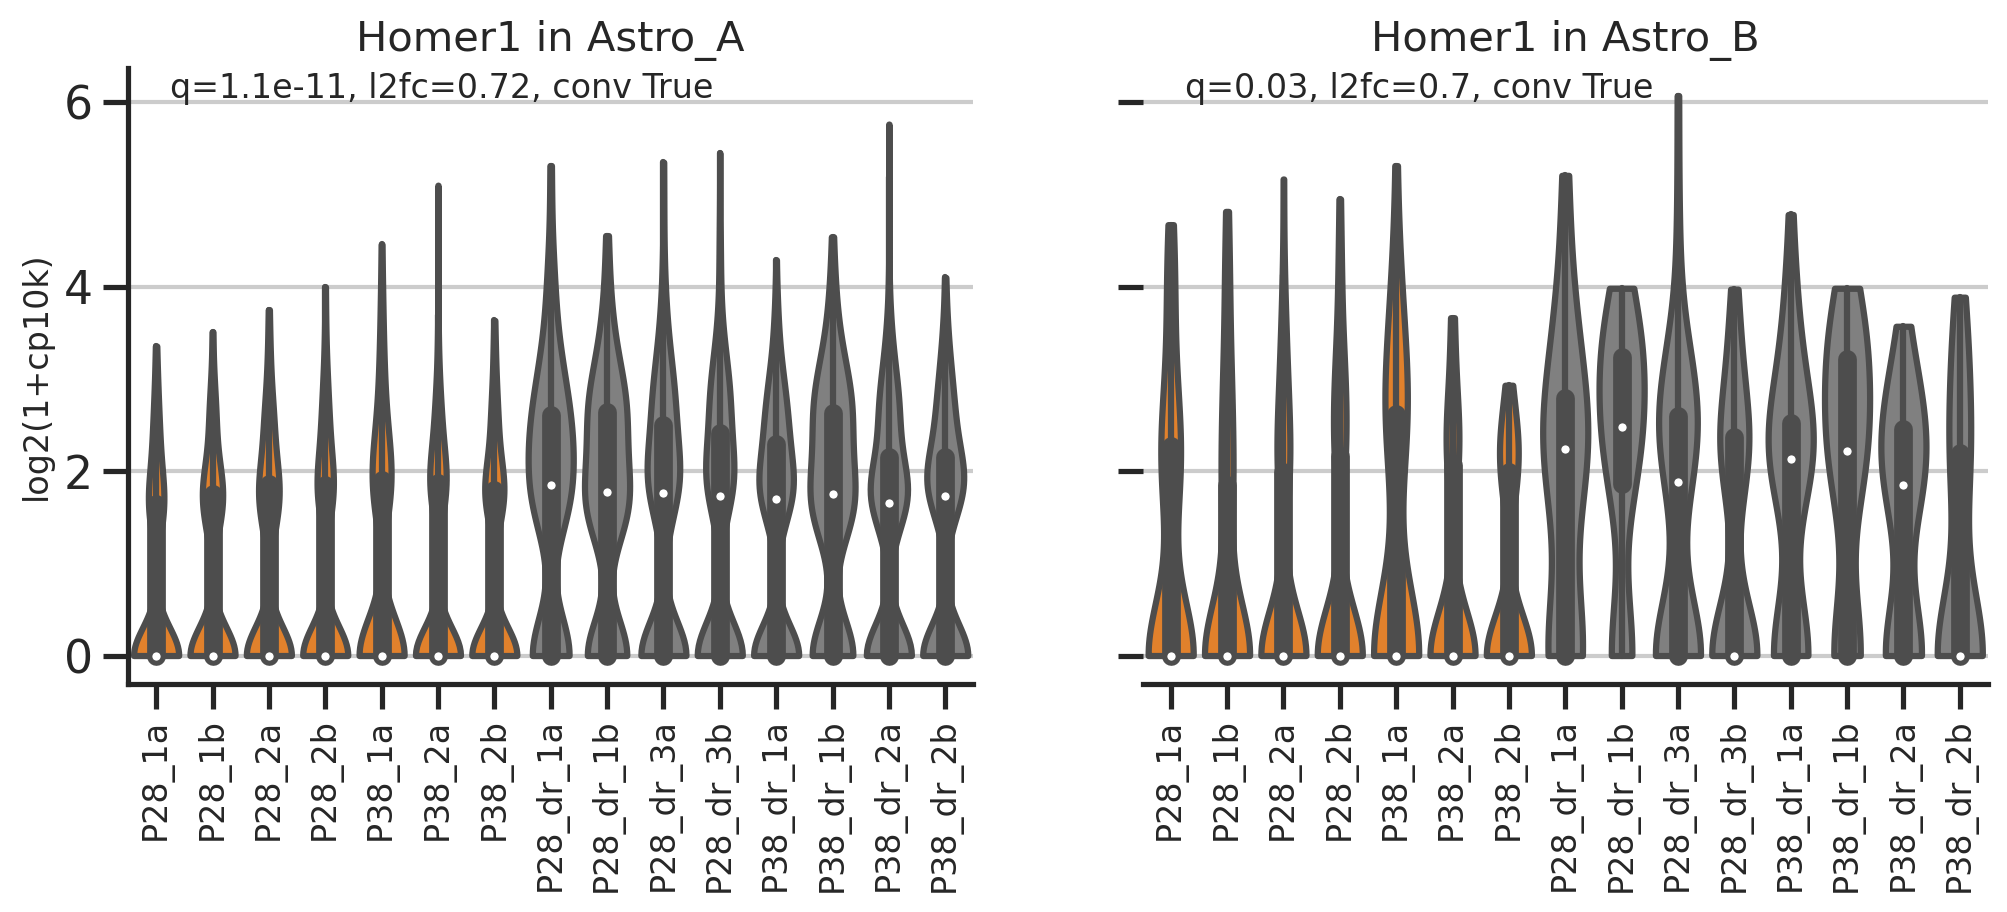

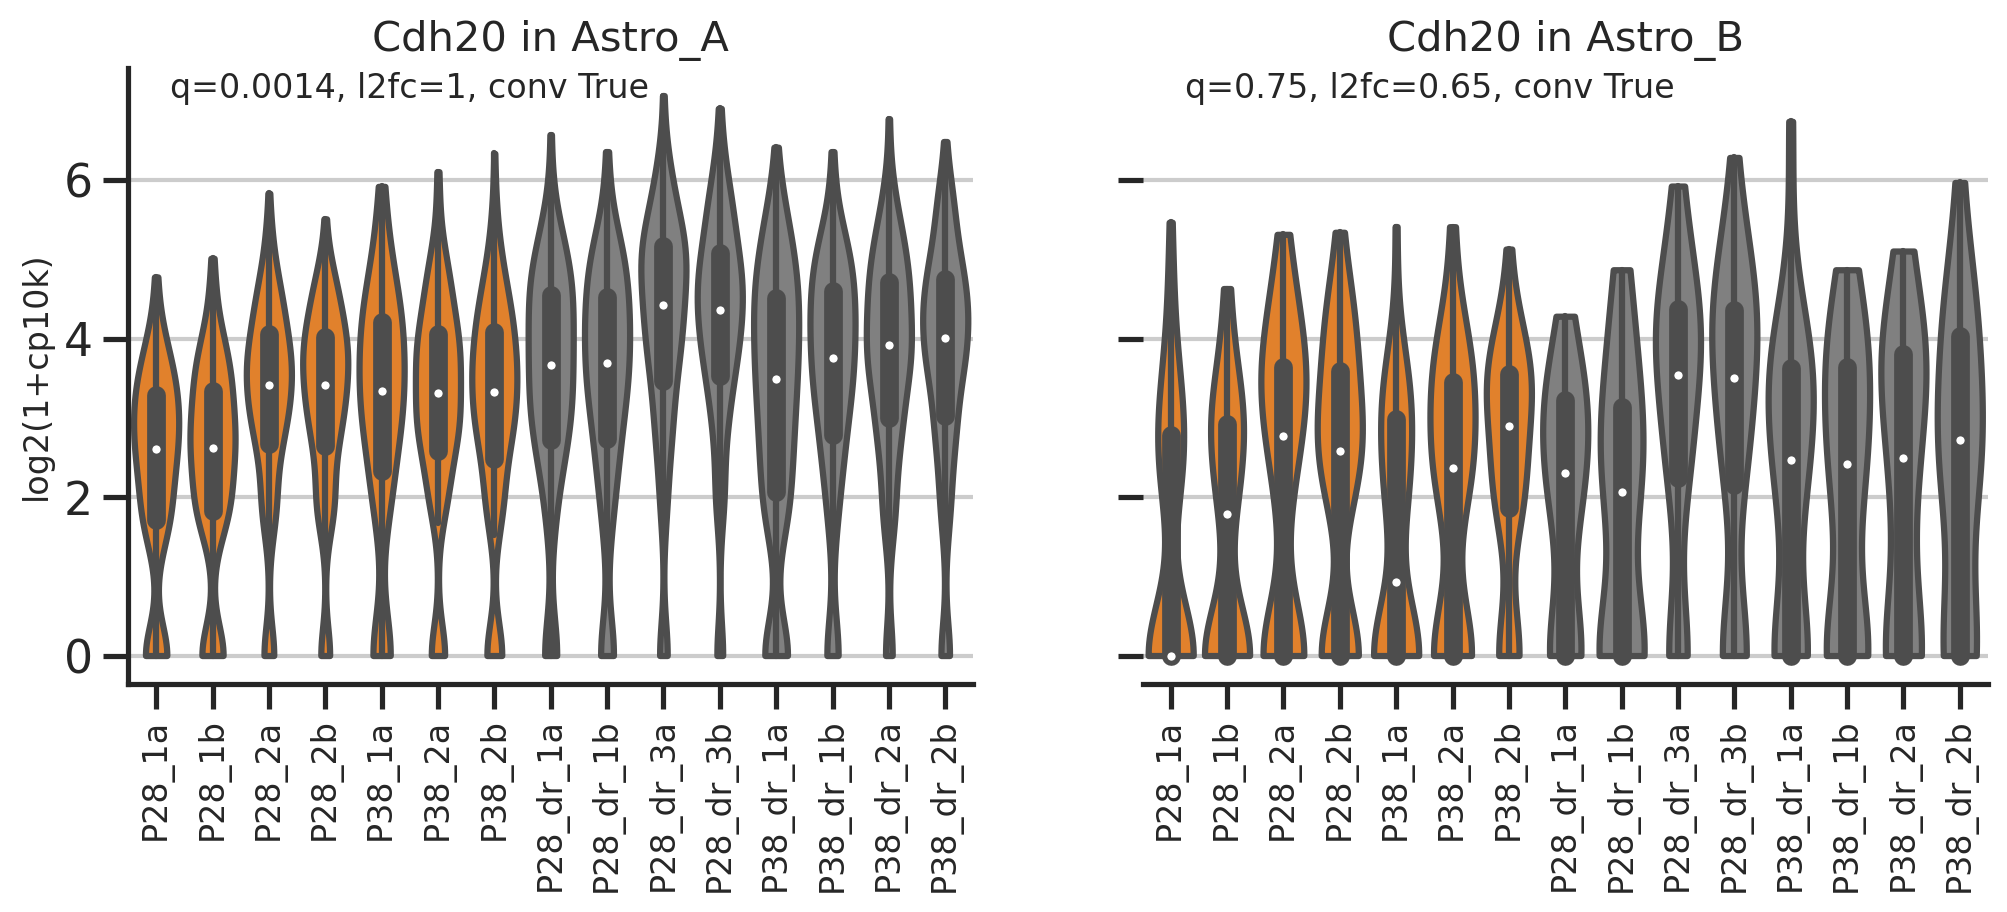

In [17]:
for gene in ['Rfx4', 'Mertk', 'Nr4a2', 'Homer1', 'Cdh20']:
    fig, axs = plt.subplots(1, 2, figsize=(12,4), sharey=True, sharex=True)
    ax = axs[0]
    df = df_raw_list[0]
    plot_one_gene_ax(gene, ax, adata_a, df)
    ax.set_title(f'{gene} in Astro_A', fontsize=15)
    ax.legend_.remove()
    
    ax = axs[1]
    df = df_raw_list[1]
    plot_one_gene_ax(gene, ax, adata_b, df)
    ax.set_title(f'{gene} in Astro_B', fontsize=15)
    ax.legend_.remove()
    sns.despine(left=True, ax=ax)
    ax.set_ylabel('')
    plt.show()

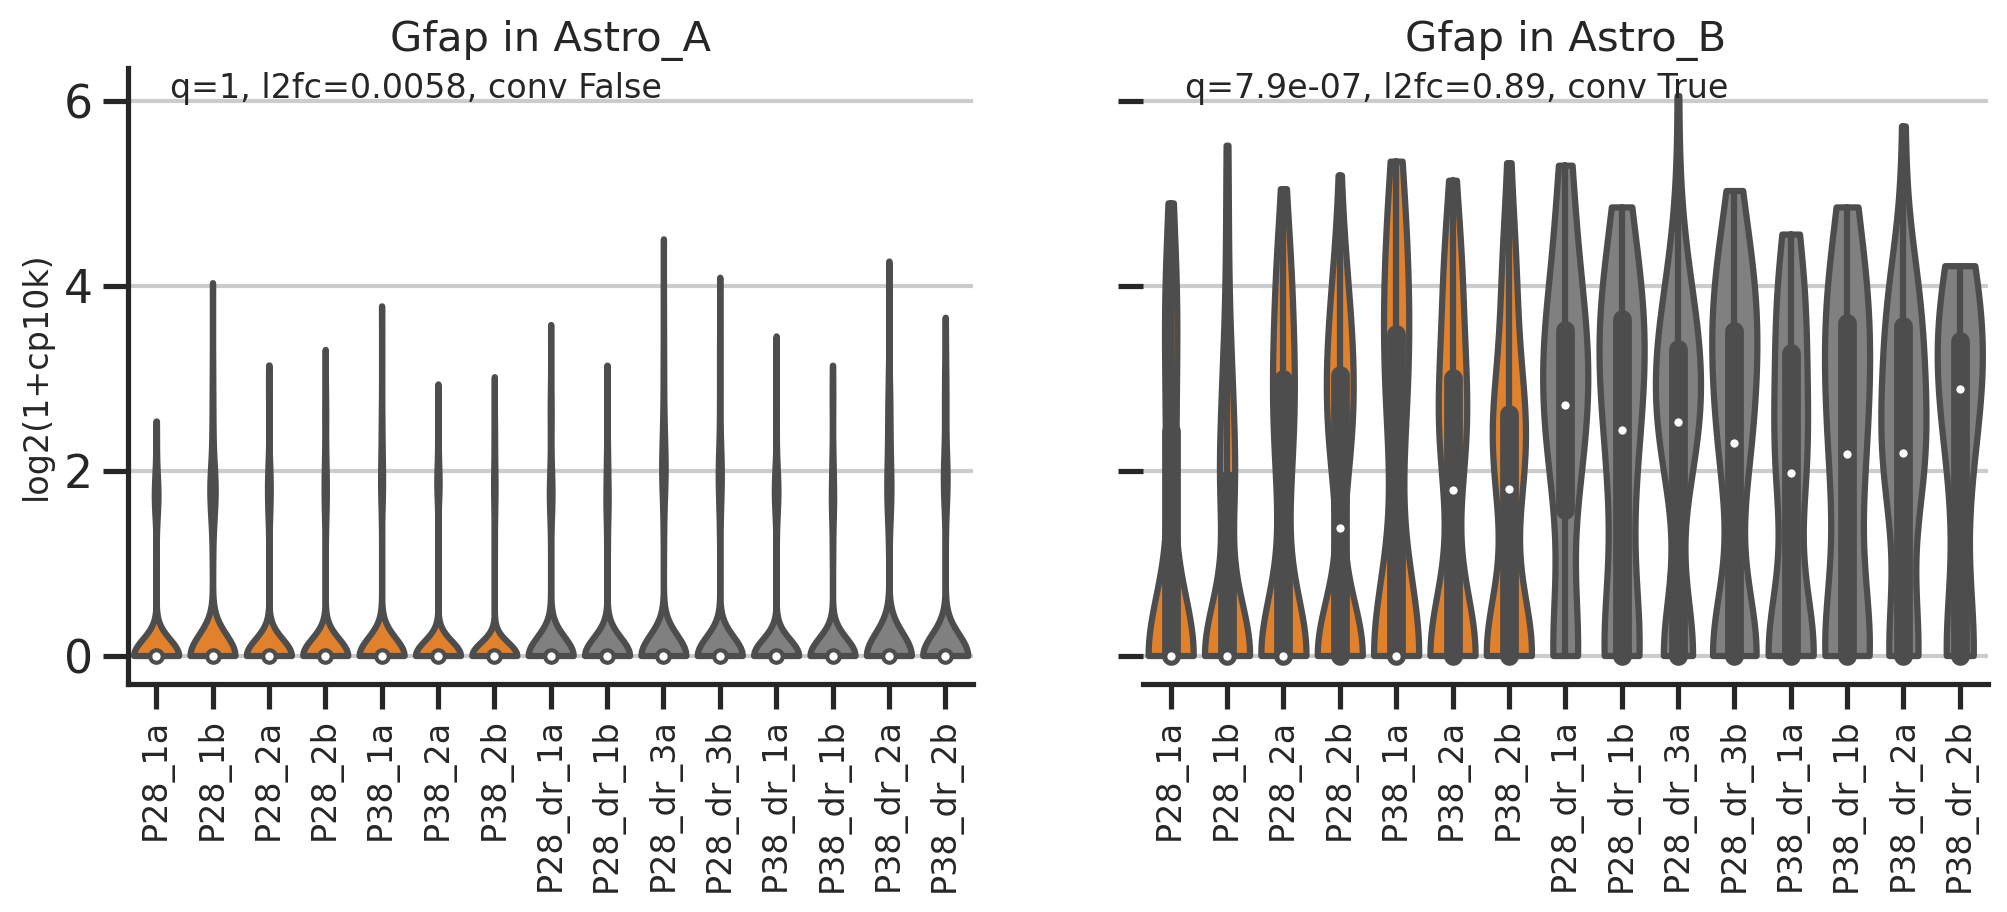

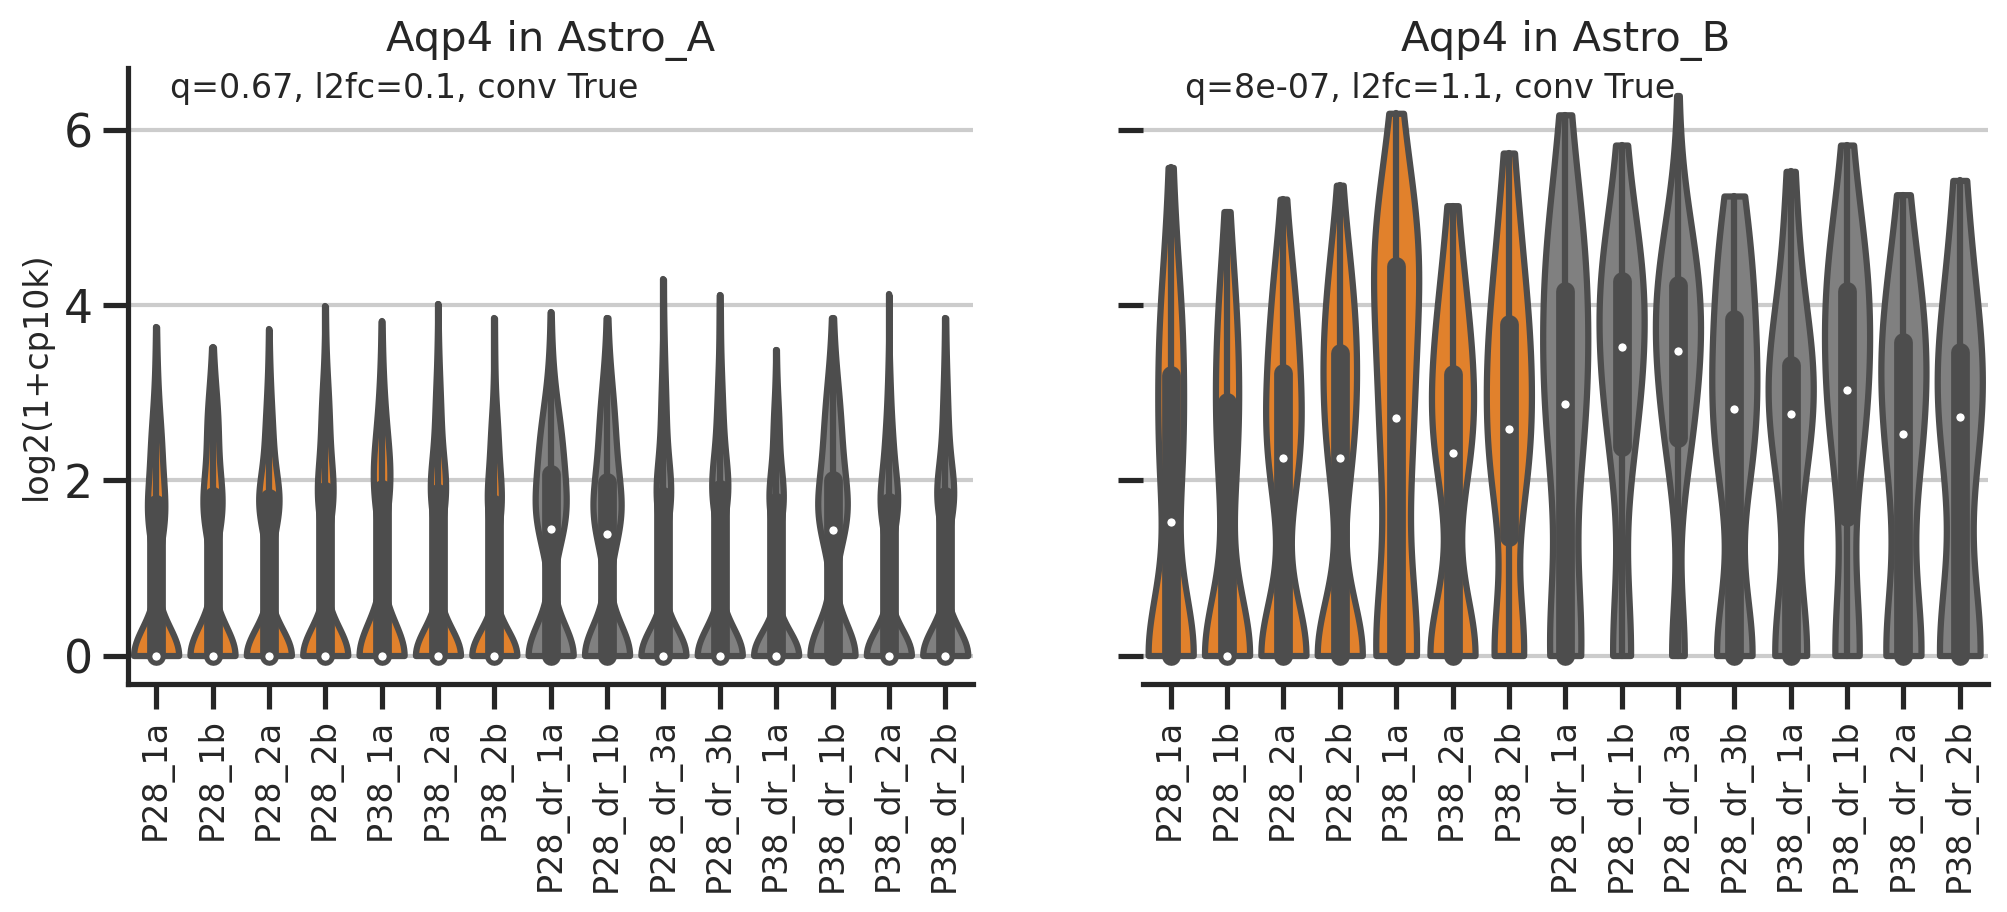

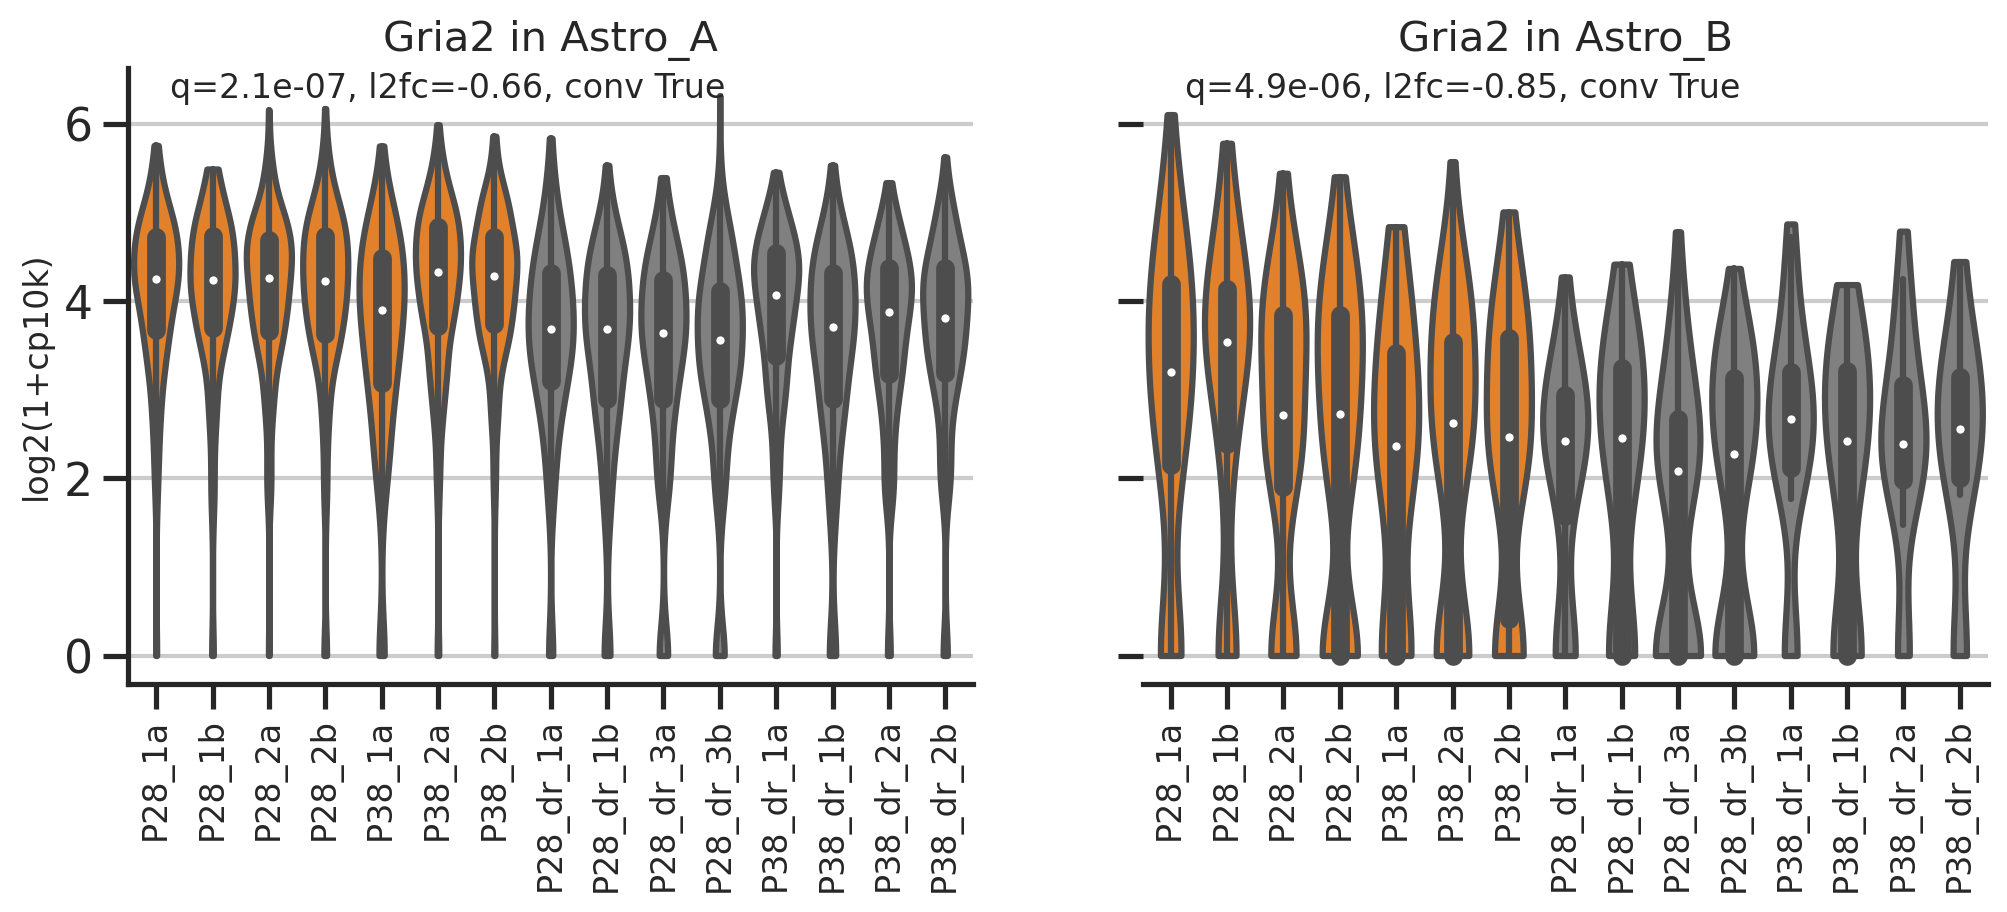

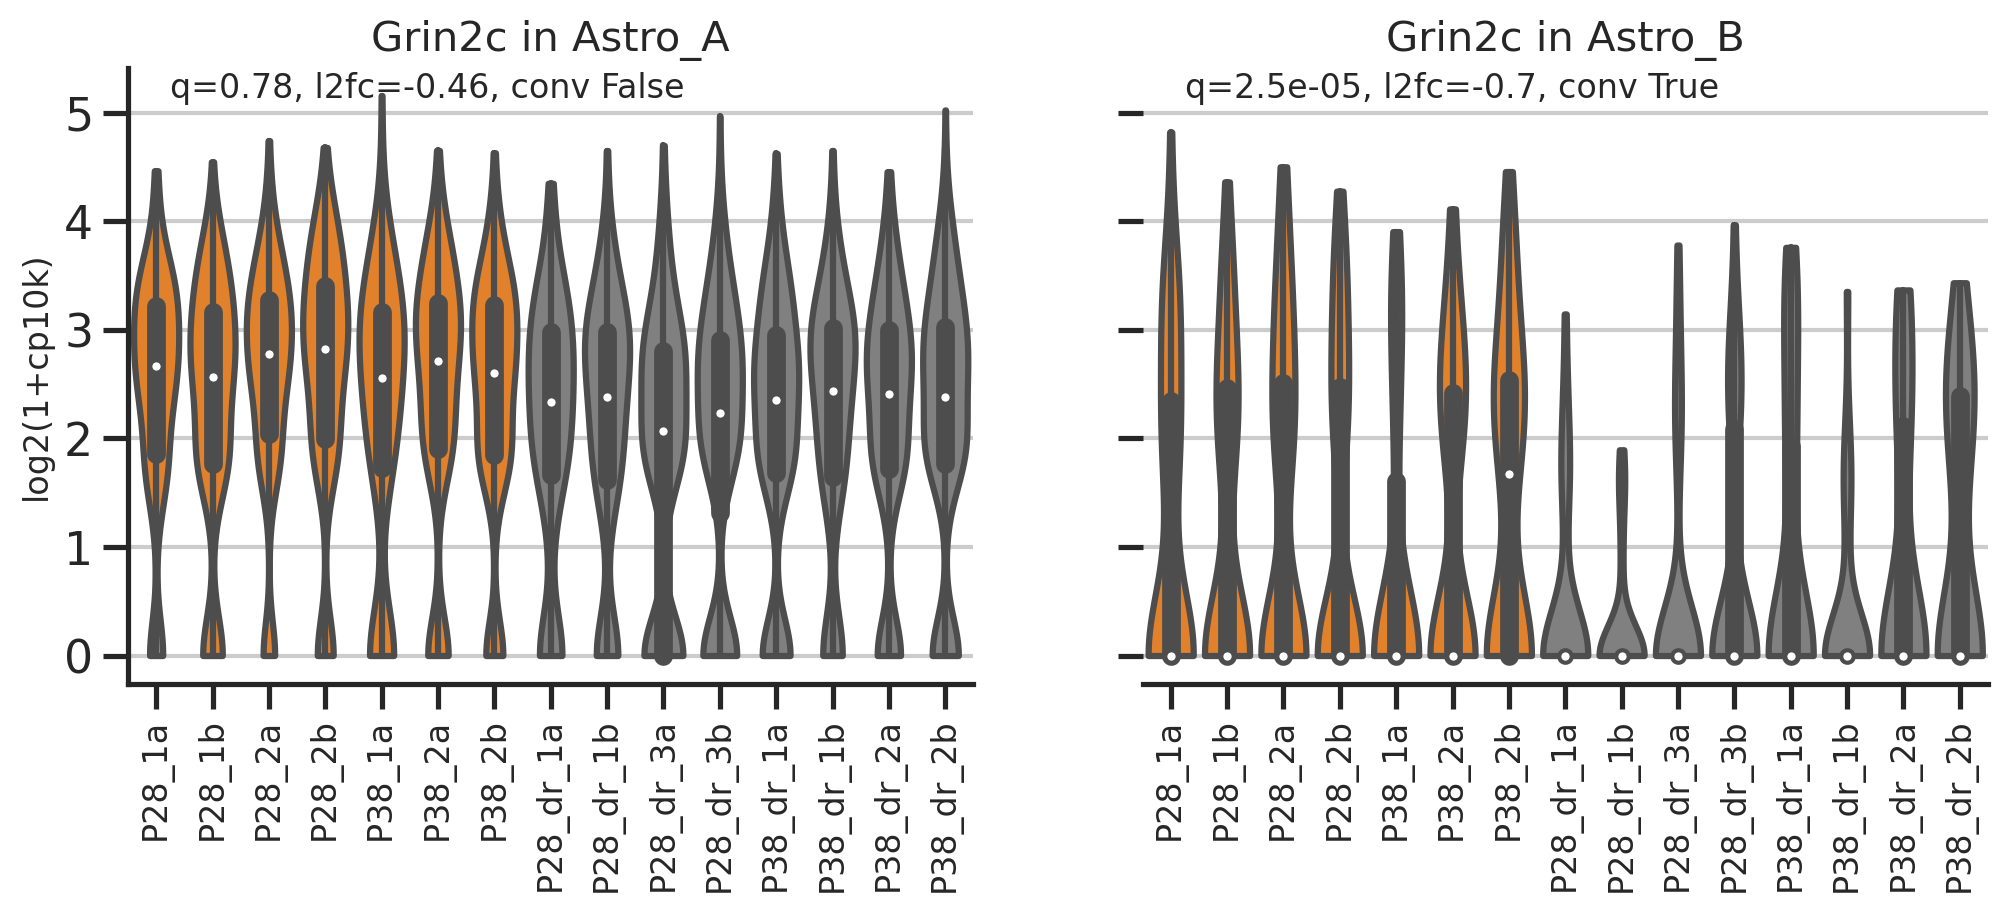

In [18]:
for gene in ['Gfap', 'Aqp4', 'Gria2', 'Grin2c']:
    fig, axs = plt.subplots(1, 2, figsize=(12,4), sharey=True, sharex=True)
    ax = axs[0]
    df = df_raw_list[0]
    plot_one_gene_ax(gene, ax, adata_a, df)
    ax.set_title(f'{gene} in Astro_A', fontsize=15)
    ax.legend_.remove()
    
    ax = axs[1]
    df = df_raw_list[1]
    plot_one_gene_ax(gene, ax, adata_b, df)
    ax.set_title(f'{gene} in Astro_B', fontsize=15)
    ax.legend_.remove()
    sns.despine(left=True, ax=ax)
    ax.set_ylabel('')
    plt.show()

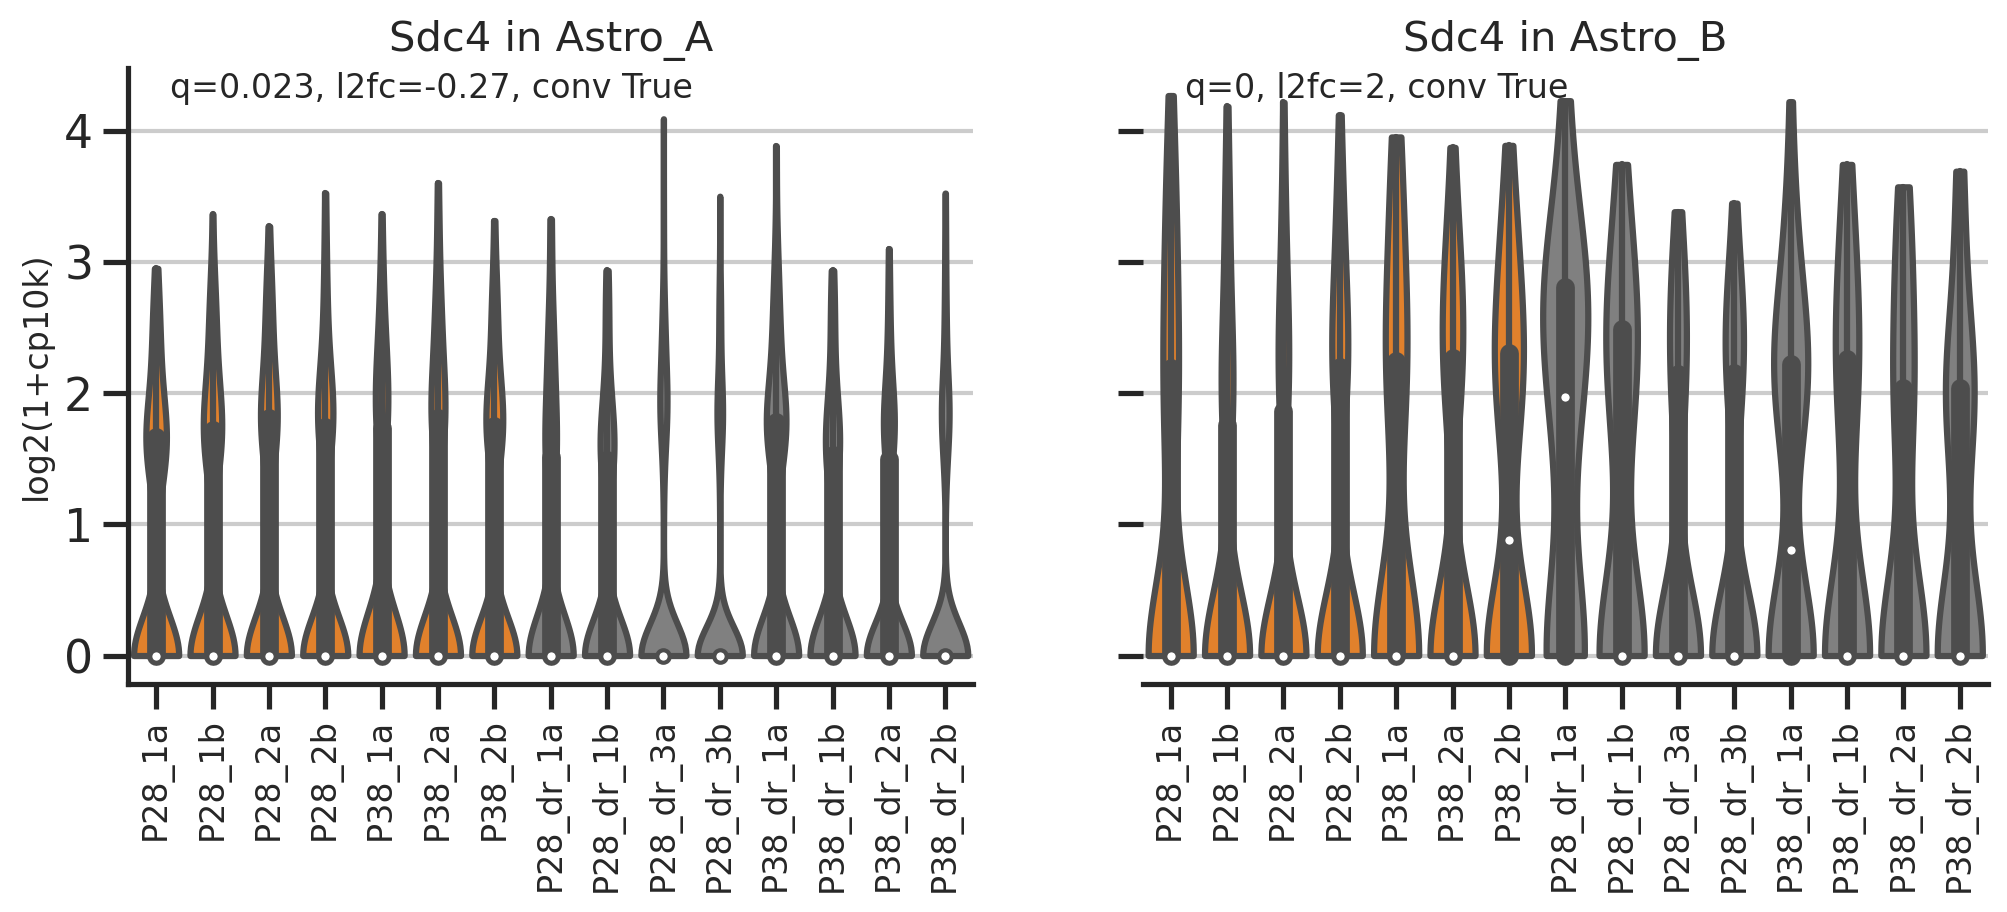

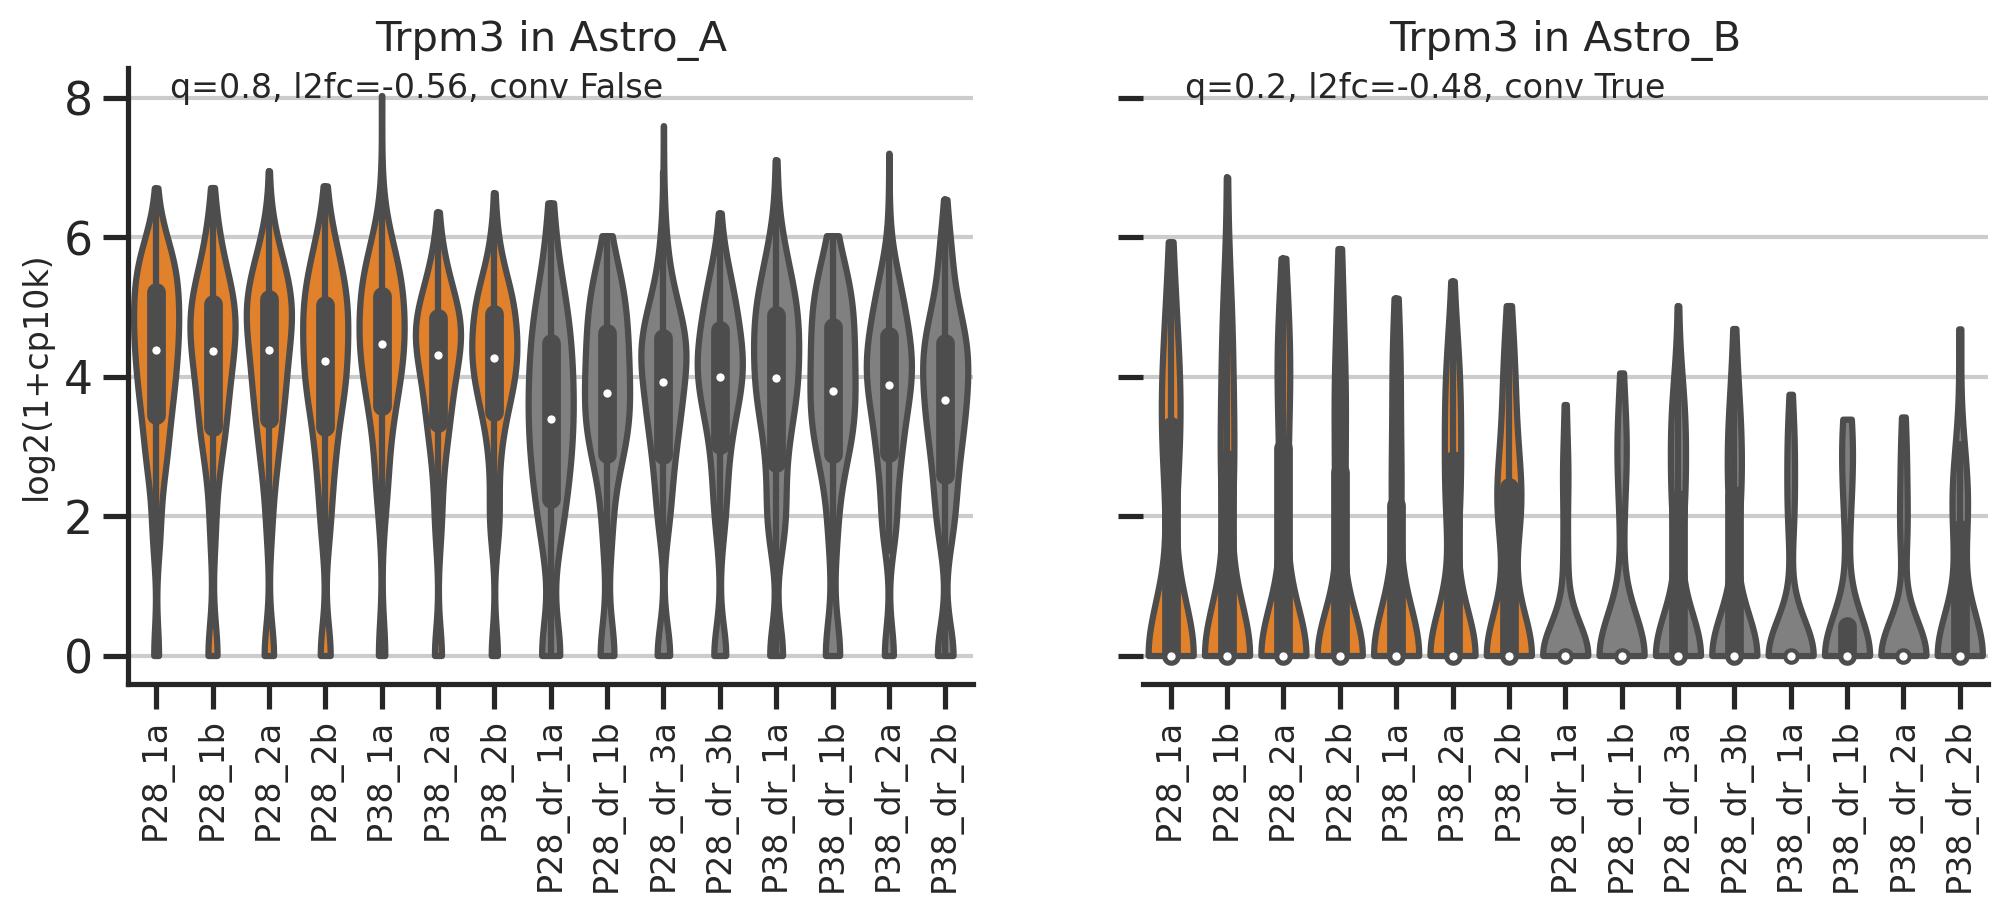

In [19]:
for gene in ['Sdc4', 'Trpm3']:
    fig, axs = plt.subplots(1, 2, figsize=(12,4), sharey=True, sharex=True)
    ax = axs[0]
    df = df_raw_list[0]
    plot_one_gene_ax(gene, ax, adata_a, df)
    ax.set_title(f'{gene} in Astro_A', fontsize=15)
    ax.legend_.remove()
    
    ax = axs[1]
    df = df_raw_list[1]
    plot_one_gene_ax(gene, ax, adata_b, df)
    ax.set_title(f'{gene} in Astro_B', fontsize=15)
    ax.legend_.remove()
    sns.despine(left=True, ax=ax)
    ax.set_ylabel('')
    plt.show()

# shared vs different